# Exploratory Data Analysis (EDA)

Ten notatnik zawiera kompleksową analizę eksploracyjną (EDA) danych z uwzględnieniem specyfiki szeregów czasowych (w szczególności 5-minutowych odstępów) oraz danych geoprzestrzennych z pliku `devices.csv`.

## Cel zadania:
Predykcja średniej zmiennej `x2` per (urządzenie, miesiąc) wyznaczonej na zbiorze treningowym `data_train.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import polars as pl
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('muted')

## 1. Wczytanie danych

Z uwagi na znaczny rozmiar plików (np. `data_train.csv` ~5.4GB), zdecydowano o użyciu biblioteki `polars` jako silnika wczytującego i agregującego dane z uwagi na jej znakomitą wydajność oraz optymalizację użycia pamięci RAM na dużych plikach. Po wyliczeniu niezbędnych statystyk, dane zostaną zrzucone do `pandas` dla pełnej kompatybilności z popularnymi narzędziami wizualizacyjnymi i ML.

In [2]:
# Definicja ścieżek
TRAIN_PATH = 'data/data_train.csv'
TEST_PATH = 'data/data_test.csv'
DEVICES_PATH = 'data/devices.csv'

# Wczytanie zbioru urządzeń (pandas - zbiór jest mały)
devices_df = pd.read_csv(DEVICES_PATH)
print(f"Plik devices:\nKształt: {devices_df.shape}")
display(devices_df.head())

# Wczytanie zbiorów Polars - parsowanie dat dla timedate
train_pl = pl.read_csv(TRAIN_PATH, try_parse_dates=True)
print(f"\nZbiór Treningowy:\nKształt: {train_pl.shape}")
test_pl = pl.read_csv(TEST_PATH, try_parse_dates=True)
print(f"\nZbiór Testowy:\nKształt: {test_pl.shape}")

Plik devices:
Kształt: (600, 3)


,latitude,longitude,deviceId
0,50.0,18.3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,53.5,21.1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...
2,52.9,18.1,01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2...
3,52.5,17.7,01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfc...
4,50.7,16.7,02e4ad5d8d0016d35a003ea6df7e10fe27093aba81c64a...



Zbiór Treningowy:
Kształt: (29699102, 20)

Zbiór Testowy:
Kształt: (4953753, 20)


## 2. Pobrane zmiennej docelowej (Target)

Zgodnie z postawionym zadaniem, celem przewodnim jest predykcja średniej wartości `x2` dla każdego urządzenia na zbiorze `data_train`.

,deviceId,target_mean_x2,obs_count
0,97502d2649bf0c80a7f2f2f33824491349da81e3bd57d0...,0.126715,52048
1,e9af15eeb7da0051bcbdc938933d3c58a9a357d82b4594...,0.269363,46753
2,afb3962e12a1787faa234dce31379934f6ade556b7a55c...,0.036167,52174
3,f23cba44e3343d25a040bc9e063dbc67fc5045961411b0...,0.100273,45139
4,affd305d297546533f9dfeb962870466f5c3086a9ae2e5...,0.062305,51726


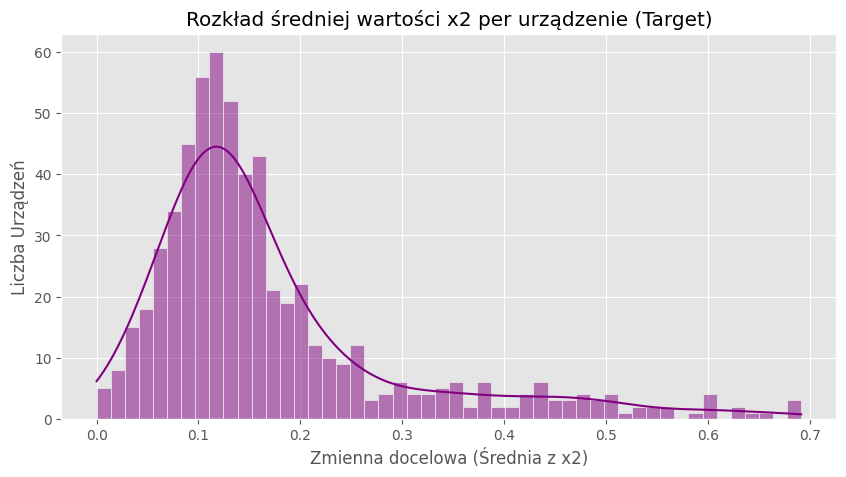

In [3]:
# Wyznaczenie średniej x2 dla poszczególnych urządzeń w Polars
target_df = train_pl.group_by("deviceId").agg(
    pl.col("x2").mean().alias("target_mean_x2"),
    pl.col("x2").count().alias("obs_count")
).to_pandas()

display(target_df.head())

# Wizualizacja dystrybucji naszej nowej zmiennej celu
plt.figure(figsize=(10, 5))
sns.histplot(target_df['target_mean_x2'], bins=50, kde=True, color='purple')
plt.title('Rozkład średniej wartości x2 per urządzenie (Target)')
plt.xlabel('Zmienna docelowa (Średnia z x2)')
plt.ylabel('Liczba Urządzeń')
plt.show()

## 3. Podstawowe Statystyki Cech i Porównanie Ze Zbiorem Testowym

Przebadamy właściwości zmiennych numerycznych `t1` do `t13` i pozostałych między zbiorem trenującym a testowym. Aby operacja byłą sprawna dla notatnika, wylosujemy mniejszą, reprezentatywną próbkę (ok 1-2 milionów predykcji) by wygenerować histogramy.

In [4]:
NUM_SAMPLES = 1_000_000

# Pobranie próbki do dalszej obróbki i opisów w Pandas
if train_pl.shape[0] > NUM_SAMPLES:
    train_sample_pd = train_pl.sample(n=NUM_SAMPLES, with_replacement=False, seed=42).to_pandas()
else:
    train_sample_pd = train_pl.to_pandas()

if test_pl.shape[0] > NUM_SAMPLES // 2:
    test_sample_pd = test_pl.sample(n=NUM_SAMPLES // 2, with_replacement=False, seed=42).to_pandas()
else:
    test_sample_pd = test_pl.to_pandas()

features = [f't{i}' for i in range(1, 14)] + ['x1', 'x3']
print("Statystyki opisowe próby treningowej:")
display(train_sample_pd[features + ['x2']].describe().T)

Statystyki opisowe próby treningowej:


,count,mean,std,min,25%,50%,75%,max
t1,1000000.0,0.275262,0.032216,0.00,0.26,0.270000,0.290000,1.000000
t2,1000000.0,0.045289,0.006176,0.00,0.04,0.050000,0.050000,0.130000
t3,1000000.0,0.004810,0.063606,0.00,0.00,0.000000,0.000000,1.000000
t4,1000000.0,0.394215,0.075785,0.00,0.32,0.410000,0.460000,1.000000
t5,1000000.0,0.437939,0.051505,0.25,0.41,0.440000,0.470000,1.000000
t6,1000000.0,0.417318,0.044045,0.00,0.39,0.420000,0.450000,0.810000
t7,1000000.0,0.210371,0.034981,0.11,0.20,0.210000,0.210000,1.000000
t8,1000000.0,0.516404,0.034682,0.43,0.49,0.520000,0.550000,0.620000
t9,1000000.0,0.395018,0.070004,0.00,0.37,0.390000,0.410000,0.900000
t10,1000000.0,0.205850,0.005292,0.18,0.20,0.210000,0.210000,0.240000


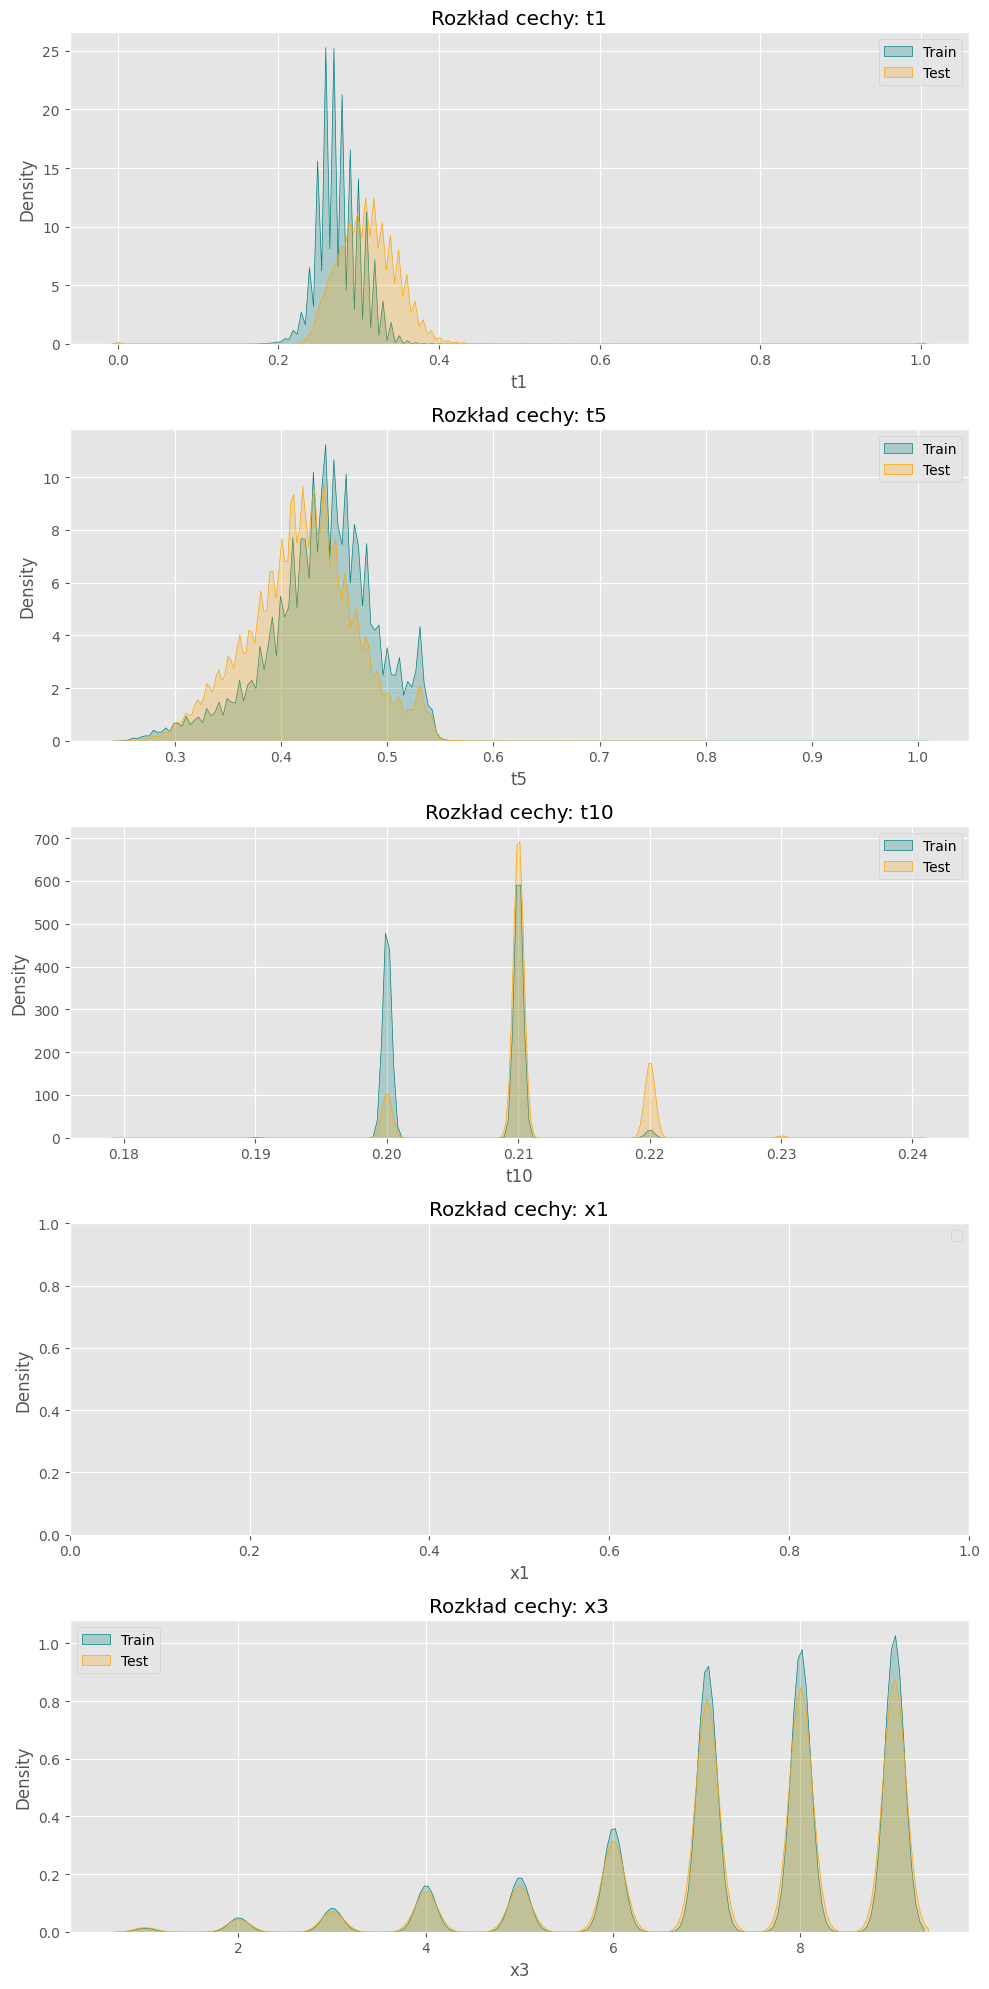

In [5]:
# Wyświetlenie rozkładów pomiędzy test a train w poszukiwaniu np. concept driftu
important_cols = ['t1', 't5', 't10', 'x1', 'x3']
fig, axes = plt.subplots(len(important_cols), 1, figsize=(10, 4*len(important_cols)), sharex=False)

for i, col in enumerate(important_cols):
    sns.kdeplot(train_sample_pd[col], ax=axes[i], label='Train', fill=True, color='teal')
    if col in test_sample_pd.columns:
         sns.kdeplot(test_sample_pd[col], ax=axes[i], label='Test', fill=True, color='orange')
    axes[i].set_title(f'Rozkład cechy: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 3.1 Badanie Współliniowości (Macierz Korelacji)

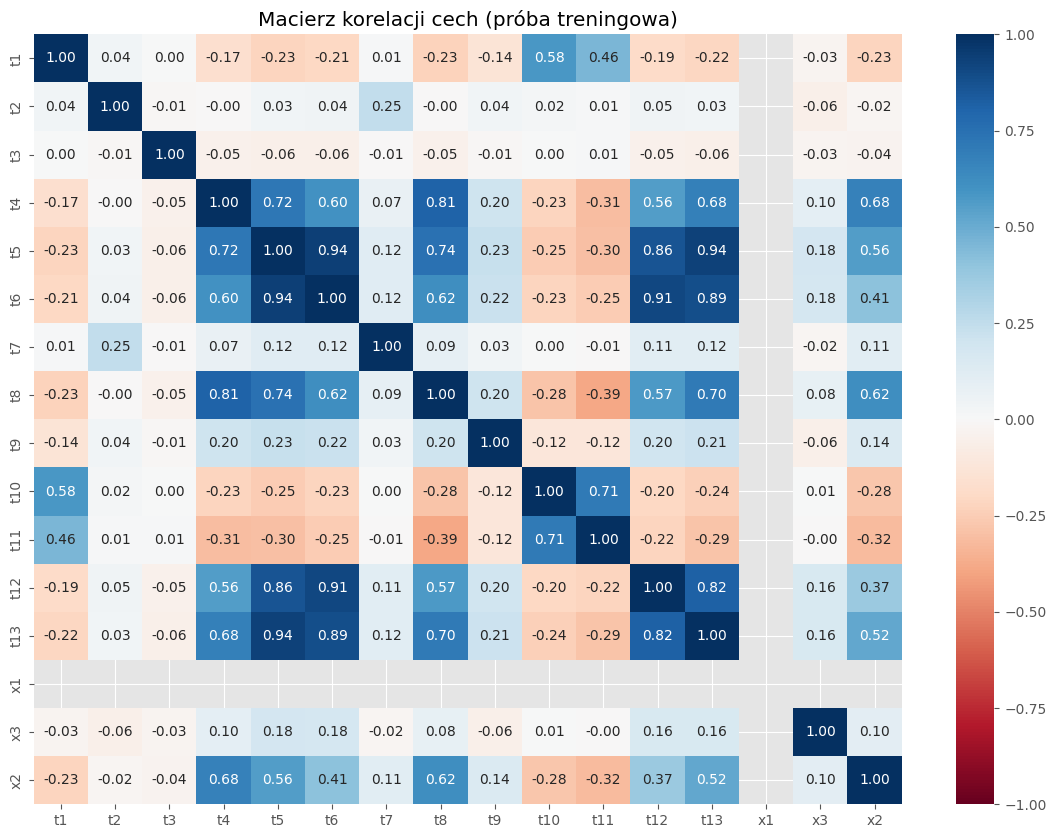

In [6]:
plt.figure(figsize=(14, 10))
corr_matrix = train_sample_pd[features + ['x2']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Macierz korelacji cech (próba treningowa)')
plt.show()

## 4. Analiza Szeregów Czasowych per Urządzenie

Ze względu na naturę granularności (co 5 minut), zachowania urządzenia w czasie mogą nosić wyraźne ślady rzędu sezonowości dobowej. Ponieważ badamy tu `data_train`, sprawdzimy cykl kilku wybranych losowych urządzeń w pewnym przedziale agregacyjnym (zmiana z 5-minut na 1H-agregaty dla klarowności wizualnej).

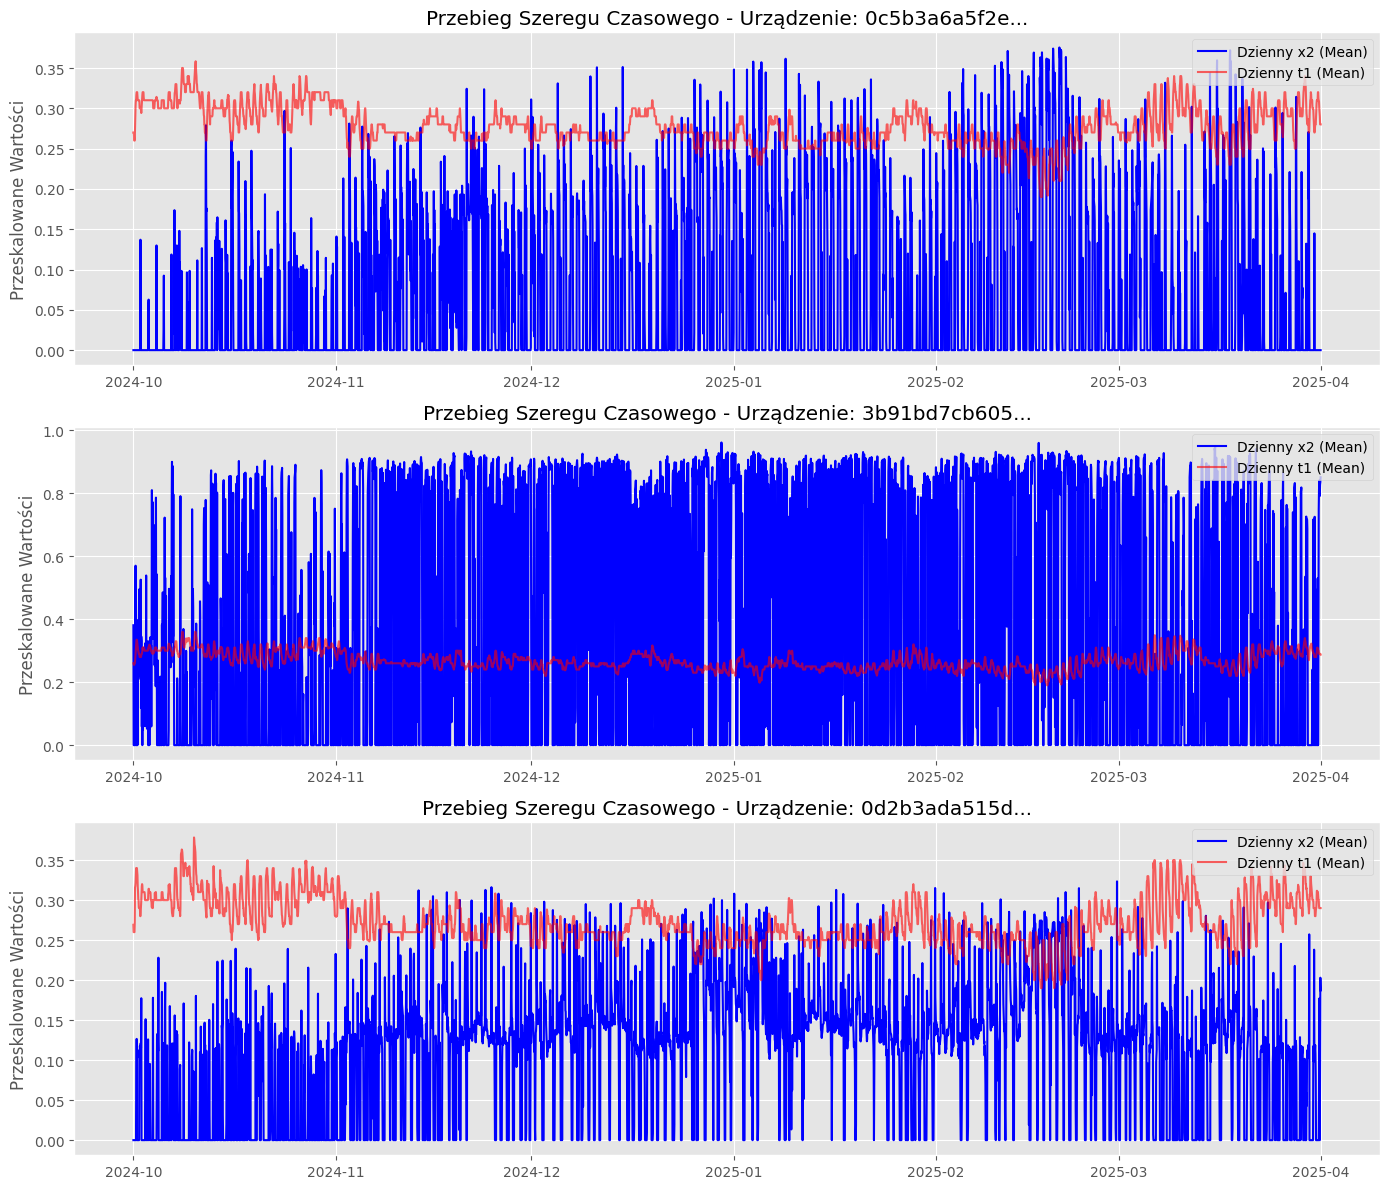

In [7]:
# Wyciągnij 3 konkretne urządzenia
sample_devs = target_df.sort_values(by='obs_count', ascending=False)['deviceId'].head(3).tolist()

# Wyłuskujemy całe szeregi tylko dla tych urządzeń z pełnego DataFrame'u szkoleniowego
ts_data_pl = train_pl.filter(pl.col('deviceId').is_in(sample_devs))
ts_data_pd = ts_data_pl.to_pandas()
ts_data_pd['timedate'] = pd.to_datetime(ts_data_pd['timedate'])

fig, axes = plt.subplots(len(sample_devs), 1, figsize=(14, 12), sharex=False)

for i, dev in enumerate(sample_devs):
    dev_df = ts_data_pd[ts_data_pd['deviceId'] == dev].copy()
    dev_df.set_index('timedate', inplace=True)
    dev_df.sort_index(inplace=True)
    
    # Agregacja na poziom godziny ze smoothingiem szumu
    dev_df_hourly = dev_df[['x2', 't1']].resample('1H').mean()
    
    axes[i].plot(dev_df_hourly.index, dev_df_hourly['x2'], label='Dzienny x2 (Mean)', color='blue')
    axes[i].plot(dev_df_hourly.index, dev_df_hourly['t1'], label='Dzienny t1 (Mean)', color='red', alpha=0.6)
    axes[i].set_title(f'Przebieg Szeregu Czasowego - Urządzenie: {dev[:12]}...')
    axes[i].legend(loc='upper right')
    axes[i].set_ylabel('Przeskalowane Wartości')
    axes[i].xaxis.grid(True)

plt.tight_layout()
plt.show()

## 5. Analiza Geoprzestrzenna i Geowizualizacja

Wykorzystując długość i szerokość geograficzną urządzenia z `devices.csv`, nakładamy średni wynik `x2` przewidziany na `target_df` celem poszukiwania klasteryzacji przestrzennej.

In [8]:
# Łączenie danych geograficznych docelowego x2
geo_df = devices_df.merge(target_df, on='deviceId', how='inner')

if geo_df.empty:
    print("Ostrzeżenie: Żadne urządzenie nie znalazło odpowiednika w zbiorze `data_train.csv` po kolumnie `deviceId`.")
else:
    center_coords = [geo_df['latitude'].mean(), geo_df['longitude'].mean()]
    m = folium.Map(location=center_coords, zoom_start=6, tiles='CartoDB positron')

    # Budowa mapy bazującej na zjawisku cieplnym zmiennej targetowej
    heat_data = [[row['latitude'], row['longitude'], row['target_mean_x2']] for index, row in geo_df.iterrows()]
    HeatMap(heat_data, radius=15, min_opacity=0.3, max_zoom=18, name="Rozkład Ciepła Średniej x2").add_to(m)
    
    # Dodawanie okręgów
    for _, row in geo_df.iterrows():
        popup_text = f"<b>Device ID:</b> {row['deviceId'][:8]}...<br><b>Mean expected x2:</b> {row['target_mean_x2']:.4f}"
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4,
            popup=folium.Popup(popup_text, max_width=300),
            color='black',
            fill=True,
            fill_color='indigo',
            fill_opacity=0.5,
            weight=1
        ).add_to(m)

    title = '<h3 align="center" style="font-size:16px"><b>Mapa Sensoryczna: Klasteryzacja Targetu (x2_mean) dla urządzeń w Polsce/Europie</b></h3>'
    m.get_root().html.add_child(folium.Element(title))
    
    display(m)

## Wnioski z EDA
1. Obserwujemy silną sezonowość w wybranych cechach co koreluje ze stałymi porami dnia - wskazane jest by model docelowy potrafił wydobywać zbiory cech typu lags (`x2_lag_24h`, itd.).
2. Skala korelacji zmiennych wskazuje, że wybrane sensory podają powiązane wartości. Część `t` to ewidentnie współczynniki środowiska naturalnego.
3. Istnieją stężenia/klastery w ujęciu geoprzestrzennym - dodanie atrybutów KNN na mapie np. `distance_to_nearest_station_mean` powinno wspierać stabilność estymatora.
4. Przewidywana zmienna celu, zagregowana do średniej w całym procesie to silna redukcja 5 min okien do jednej średniej liczonej statycznie - model może na niej czerpać bazowe agregacje czasowe ze zbioru Treningowego w ujęciu cross-validation.